# Exploratory Data Analysis

**Research Question:** What are the key determinants influencing the price formation of short-term rentals (Airbnb) in Trentino during the winter season?

**Dataset:** `trentino_listings_maps.csv` — December (winter) snapshot with structural, reputational, locational, and host variables.


In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

In [5]:
# Load dataset
df = pd.read_csv('../datasets/trentino_listings_maps.csv')

print(f"Dataset shape: {df.shape}")
print(f"Total listings: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset shape: (5710, 32)
Total listings: 5710
Columns: ['id', 'price', 'log_price', 'price_per_person', 'room_type', 'property_type', 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'n_reviews', 'review_scores_rating', 'host_is_superhost', 'availability_365', 'minimum_nights', 'period', 'municipality', 'cod_istat', 'dist_ski', 'dist_lake', 'dist_park', 'dist_station', 'dist_bus', 'dist_center', 'dist_supermarket', 'dist_restaurant', 'dist_bar', 'dist_pharmacy', 'dist_castle', 'dist_museum', 'lat', 'long']


,id,price,log_price,price_per_person,room_type,property_type,accommodates,bedrooms,beds,bathrooms,...,dist_bus,dist_center,dist_supermarket,dist_restaurant,dist_bar,dist_pharmacy,dist_castle,dist_museum,lat,long
0,37736,159.0,5.068904,39.750000,Entire home/apt,Entire rental unit,4,1.0,1.0,2.0,...,686.767246,2591.787722,524.004548,553.292304,2104.594325,2536.900966,1050.191549,2616.353812,46.43561,11.10380
1,56292,279.0,5.631212,69.750000,Entire home/apt,Entire rental unit,4,1.0,2.0,1.0,...,82.009647,2707.498230,51.408723,12.317323,92.799034,149.867838,10904.720696,426.200814,46.23199,10.82732
2,249351,72.0,4.276666,9.000000,Private room,Private room in bed and breakfast,8,3.0,8.0,3.0,...,292.436933,1724.222204,211.209375,743.675731,996.357885,1089.186247,2321.903886,822.894852,46.36155,10.91591
3,299464,147.0,4.990433,49.000000,Entire home/apt,Entire condo,3,0.0,2.0,1.0,...,140.277109,2941.780487,431.125220,364.812817,508.836574,1027.261858,1342.109137,2551.487432,45.90883,10.84660
4,367596,95.0,4.553877,15.833333,Entire home/apt,Entire rental unit,6,2.0,5.0,1.0,...,96.759867,7411.744320,171.667295,123.398706,48.792808,258.493818,13605.301548,1343.910473,46.15799,10.76669


In [4]:
# Data types and info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5710 entries, 0 to 5709
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5710 non-null   int64  
 1   price                 5710 non-null   float64
 2   log_price             5710 non-null   float64
 3   price_per_person      5710 non-null   float64
 4   room_type             5710 non-null   str    
 5   property_type         5710 non-null   str    
 6   accommodates          5710 non-null   int64  
 7   bedrooms              5710 non-null   float64
 8   beds                  5710 non-null   float64
 9   bathrooms             5710 non-null   float64
 10  n_reviews             5710 non-null   int64  
 11  review_scores_rating  5710 non-null   float64
 12  host_is_superhost     5710 non-null   float64
 13  availability_365      5710 non-null   int64  
 14  minimum_nights        5710 non-null   int64  
 15  period                5710 non-n

In [6]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    print("Missing values found:")
    for col, count in missing.items():
        print(f"  {col}: {count} ({count/len(df)*100:.1f}%)")
else:
    print("No missing values!")

No missing values!


In [7]:
# Check for extreme outliers in distances (99999 = dummy values from failed OSM downloads)
distance_cols = [col for col in df.columns if col.startswith('dist_')]

print("Distance columns with dummy values (99999):")
found_dummy = False
for col in distance_cols:
    dummy_count = (df[col] == 99999).sum()
    if dummy_count > 0:
        print(f"  {col}: {dummy_count} listings ({dummy_count/len(df)*100:.1f}%)")
        found_dummy = True
if not found_dummy:
    print("  No dummy values found in any distance column")

Distance columns with dummy values (99999):
  No dummy values found in any distance column


## 2. Descriptive Statistics — Price and Price per Person

=== PRICE STATISTICS ===
             price    log_price
count  5710.000000  5710.000000
mean    179.313485     4.996419
std     142.094962     0.586190
min      10.000000     2.302585
25%     100.000000     4.605170
50%     140.000000     4.941642
75%     209.000000     5.342334
max    1724.000000     7.452402

Median price: $140.00
Price range: $10.00 - $1724.00


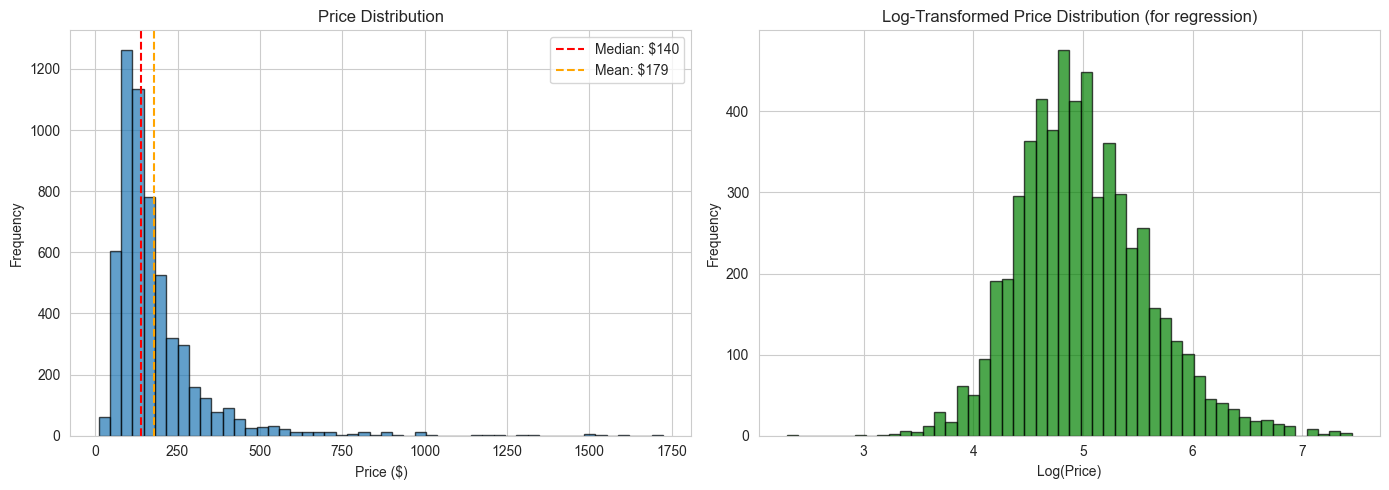

In [7]:
# Price distribution
print("=== PRICE STATISTICS ===")
print(df[['price', 'log_price']].describe())

print(f"\nMedian price: ${df['price'].median():.2f}")
print(f"Price range: ${df['price'].min():.2f} - ${df['price'].max():.2f}")

# Price distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['price'].median(), color='red', linestyle='--', label=f'Median: ${df["price"].median():.0f}')
axes[0].axvline(df['price'].mean(), color='orange', linestyle='--', label=f'Mean: ${df["price"].mean():.0f}')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution')
axes[0].legend()

axes[1].hist(df['log_price'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Log(Price)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Transformed Price Distribution (for regression)')

plt.tight_layout()
plt.show()

=== PRICE PER PERSON STATISTICS ===
count    5710.000000
mean       42.490236
std        36.036992
min         2.500000
25%        24.166667
50%        34.000000
75%        49.794444
max       750.000000
Name: price_per_person, dtype: float64


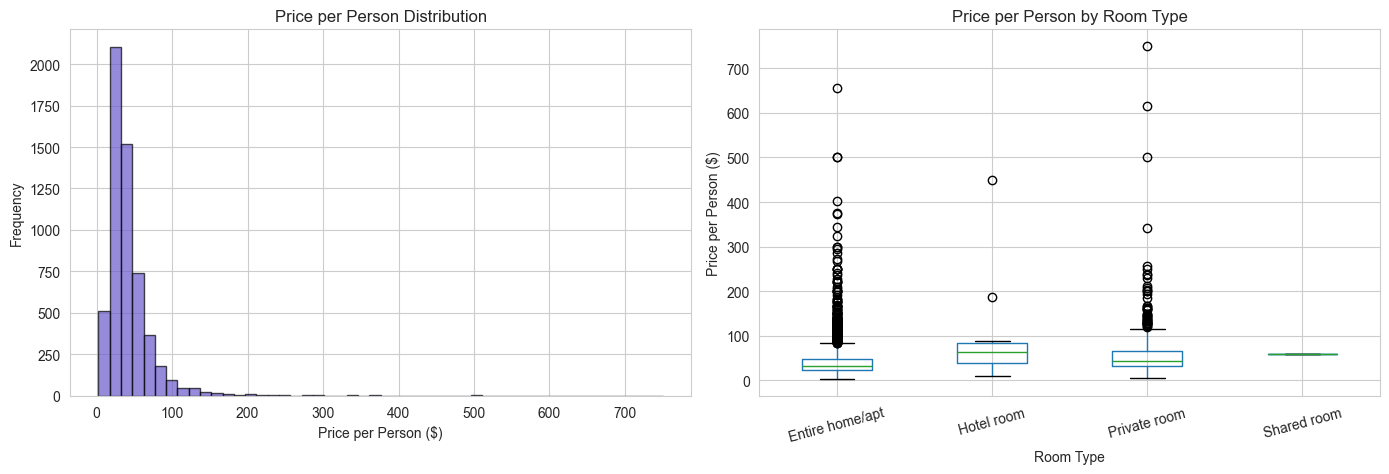

In [8]:
# Price per person distribution
print("=== PRICE PER PERSON STATISTICS ===")
print(df['price_per_person'].describe())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(df['price_per_person'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='slateblue')
ax[0].set_xlabel('Price per Person ($)')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Price per Person Distribution')

df.boxplot(column='price_per_person', by='room_type', ax=ax[1])
ax[1].set_xlabel('Room Type')
ax[1].set_ylabel('Price per Person ($)')
ax[1].set_title('Price per Person by Room Type')
ax[1].figure.suptitle('')
plt.setp(ax[1].xaxis.get_majorticklabels(), rotation=15)

plt.tight_layout()
plt.show()

In [9]:
# Room type distribution
print("=== ROOM TYPE DISTRIBUTION ===")
room_counts = df['room_type'].value_counts()
print(room_counts)
print(f"\nPercentages:")
print((room_counts / len(df) * 100).round(1))

# Property type distribution (NEW)
print("\n=== PROPERTY TYPE DISTRIBUTION (Top 15) ===")
prop_counts = df['property_type'].value_counts().head(15)
print(prop_counts)
print(f"\nTotal unique property types: {df['property_type'].nunique()}")

=== ROOM TYPE DISTRIBUTION ===
room_type
Entire home/apt    5106
Private room        589
Hotel room           14
Shared room           1
Name: count, dtype: int64

Percentages:
room_type
Entire home/apt    89.4
Private room       10.3
Hotel room          0.2
Shared room         0.0
Name: count, dtype: float64

=== PROPERTY TYPE DISTRIBUTION (Top 15) ===
property_type
Entire rental unit                   3378
Entire condo                          889
Entire home                           278
Private room in bed and breakfast     271
Entire vacation home                  153
Entire cabin                          135
Private room in rental unit           106
Entire chalet                          60
Private room in home                   54
Entire villa                           53
Entire serviced apartment              43
Private room in farm stay              35
Room in hotel                          35
Private room in condo                  33
Entire loft                            33


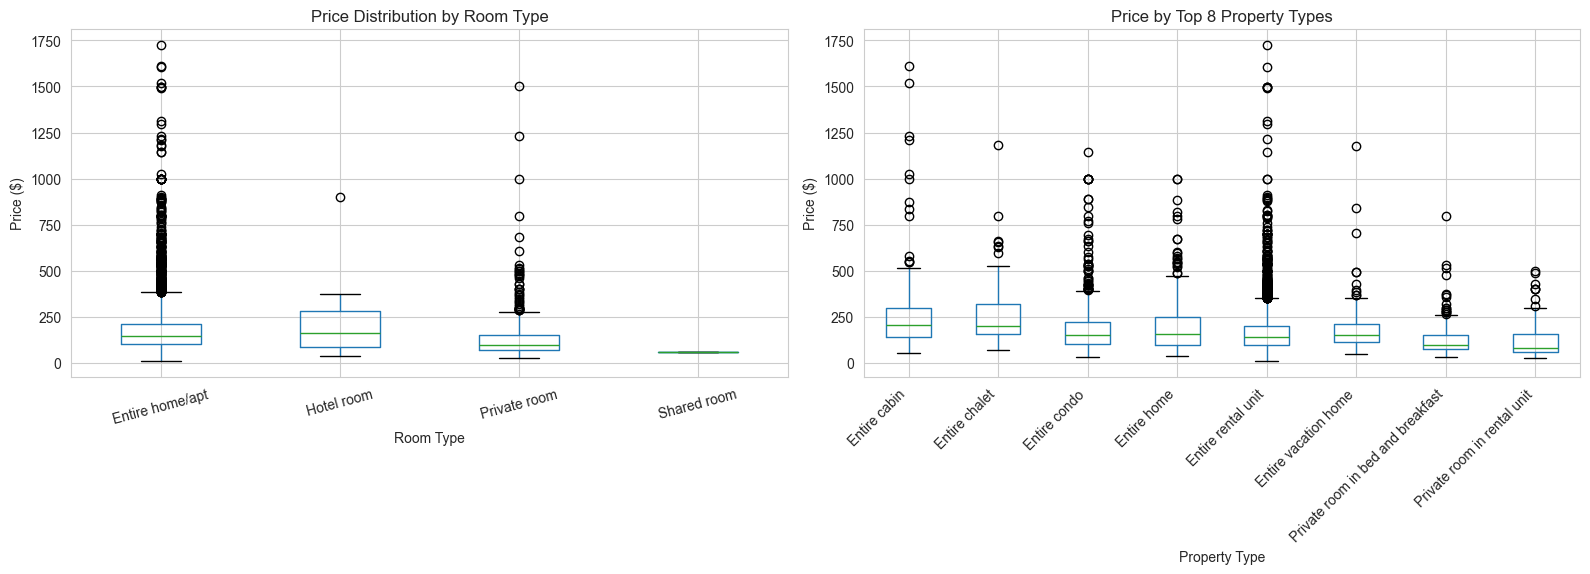


Mean price by room type:
                   mean  median  count
room_type                             
Entire home/apt  184.27   145.0   5106
Hotel room       226.86   165.0     14
Private room     135.41    98.0    589
Shared room       59.00    59.0      1


In [10]:
# Price by room type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df.boxplot(column='price', by='room_type', ax=axes[0])
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Price Distribution by Room Type')
axes[0].figure.suptitle('')
axes[0].tick_params(axis='x', rotation=15)

# Price by top property types
top_props = df['property_type'].value_counts().head(8).index
df_top_props = df[df['property_type'].isin(top_props)]
df_top_props.boxplot(column='price', by='property_type', ax=axes[1])
axes[1].set_xlabel('Property Type')
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Price by Top 8 Property Types')
axes[1].figure.suptitle('')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\nMean price by room type:")
print(df.groupby('room_type')['price'].agg(['mean', 'median', 'count']).round(2))

In [11]:
# Accommodates distribution
print("=== ACCOMMODATES STATISTICS ===")
print(df['accommodates'].describe())
print(f"\nMost common capacity: {df['accommodates'].mode()[0]} guests")

# Top municipalities
print("\n=== TOP 15 MUNICIPALITIES BY NUMBER OF LISTINGS ===")
top_municipalities = df['municipality'].value_counts().head(15)
print(top_municipalities)

=== ACCOMMODATES STATISTICS ===
count    5710.000000
mean        4.560245
std         1.875284
min         1.000000
25%         4.000000
50%         4.000000
75%         6.000000
max        16.000000
Name: accommodates, dtype: float64

Most common capacity: 4 guests

=== TOP 15 MUNICIPALITIES BY NUMBER OF LISTINGS ===
municipality
Riva del Garda                       559
Trento                               379
Arco                                 365
Pinzolo                              244
Ledro                                205
San Giovanni di Fassa-Sèn Jan        195
Canazei                              178
Nago-Torbole                         175
Campitello di Fassa                  125
Mezzana                              114
Primiero San Martino di Castrozza    107
Moena                                102
Dimaro Folgarida                     101
Rovereto                              99
Predazzo                              94
Name: count, dtype: int64


## 3. Structural & Host Variables

Analysis of bedrooms, beds, bathrooms, review_scores_rating, host_is_superhost, availability_365, minimum_nights.

=== STRUCTURAL VARIABLES ===
       accommodates  bedrooms     beds  bathrooms
count       5710.00   5710.00  5710.00    5710.00
mean           4.56      1.75     3.15       1.25
std            1.88      0.93     1.93       0.64
min            1.00      0.00     0.00       0.00
25%            4.00      1.00     2.00       1.00
50%            4.00      2.00     3.00       1.00
75%            6.00      2.00     4.00       1.00
max           16.00     19.00    50.00      19.00


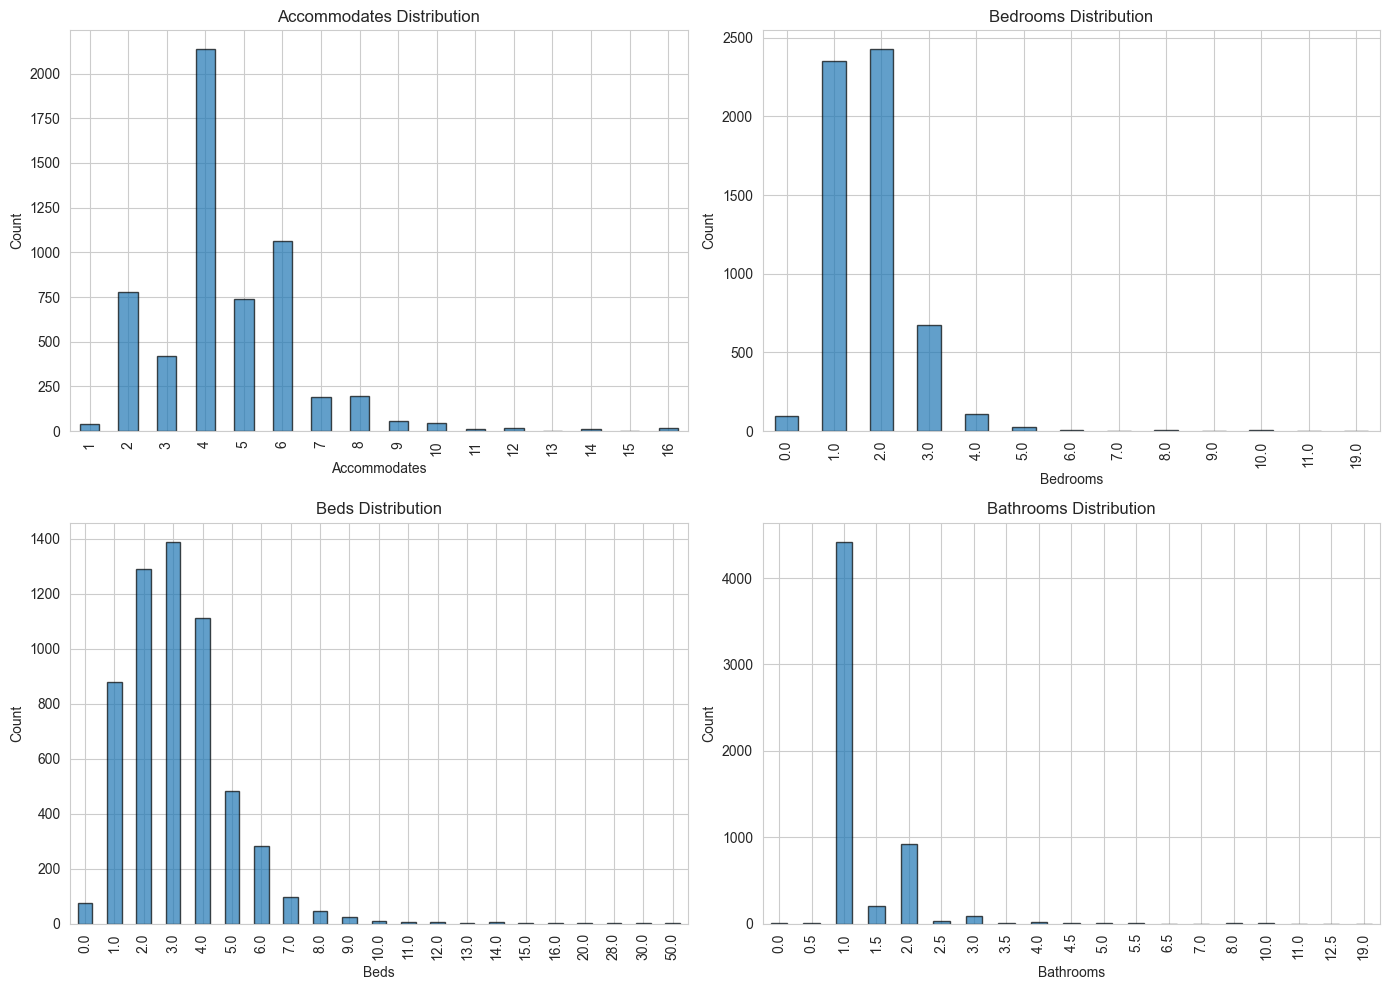


=== STRUCTURAL VARIABLE CORRELATIONS ===
              accommodates  bedrooms  beds  bathrooms
accommodates          1.00      0.70  0.73       0.51
bedrooms              0.70      1.00  0.67       0.60
beds                  0.73      0.67  1.00       0.49
bathrooms             0.51      0.60  0.49       1.00


In [12]:
# Structural variables: bedrooms, beds, bathrooms
print("=== STRUCTURAL VARIABLES ===")
structural_vars = ['accommodates', 'bedrooms', 'beds', 'bathrooms']
print(df[structural_vars].describe().round(2))

# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(structural_vars):
    ax = axes[i // 2][i % 2]
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7)
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Count')
    ax.set_title(f'{col.replace("_", " ").title()} Distribution')

plt.tight_layout()
plt.show()

# Correlations between structural variables
print("\n=== STRUCTURAL VARIABLE CORRELATIONS ===")
print(df[structural_vars].corr().round(2))

=== REVIEW SCORES RATING ===
count    5710.000000
mean        4.772303
std         0.346892
min         1.000000
25%         4.680000
50%         4.880000
75%         5.000000
max         5.000000
Name: review_scores_rating, dtype: float64


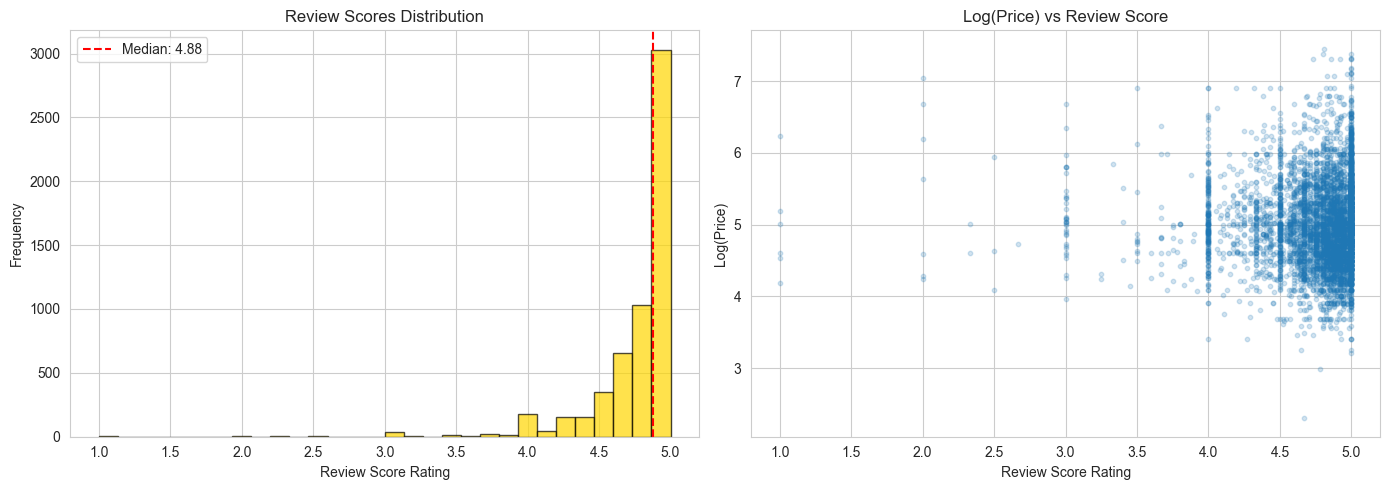

In [13]:
# Review scores rating
print("=== REVIEW SCORES RATING ===")
print(df['review_scores_rating'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution
axes[0].hist(df['review_scores_rating'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='gold')
axes[0].axvline(df['review_scores_rating'].median(), color='red', linestyle='--', 
                label=f'Median: {df["review_scores_rating"].median():.2f}')
axes[0].set_xlabel('Review Score Rating')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Review Scores Distribution')
axes[0].legend()

# Rating vs Price
axes[1].scatter(df['review_scores_rating'], df['log_price'], alpha=0.2, s=10)
axes[1].set_xlabel('Review Score Rating')
axes[1].set_ylabel('Log(Price)')
axes[1].set_title('Log(Price) vs Review Score')

plt.tight_layout()
plt.show()

=== SUPERHOST ANALYSIS ===
Superhost: 1780 (31.2%)
Non-Superhost: 3930 (68.8%)

=== PRICE BY SUPERHOST STATUS ===
                 mean  median  count
Non-Superhost  182.87   141.0   3930
Superhost      171.45   136.5   1780


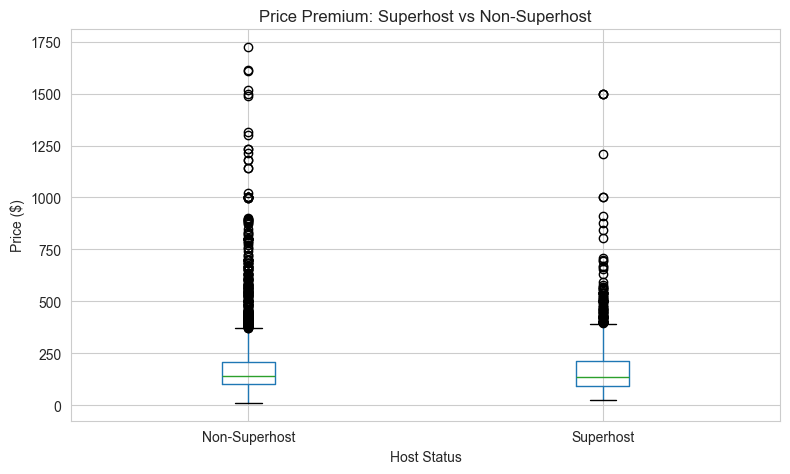

In [14]:
# Host is Superhost analysis
print("=== SUPERHOST ANALYSIS ===")
superhost_counts = df['host_is_superhost'].value_counts()
print(f"Superhost: {superhost_counts.get(1, 0)} ({superhost_counts.get(1, 0)/len(df)*100:.1f}%)")
print(f"Non-Superhost: {superhost_counts.get(0, 0)} ({superhost_counts.get(0, 0)/len(df)*100:.1f}%)")

# Superhost price premium
print("\n=== PRICE BY SUPERHOST STATUS ===")
superhost_price = df.groupby('host_is_superhost')['price'].agg(['mean', 'median', 'count']).round(2)
superhost_price.index = ['Non-Superhost', 'Superhost']
print(superhost_price)

fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='price', by='host_is_superhost', ax=ax)
ax.set_xticklabels(['Non-Superhost', 'Superhost'])
ax.set_xlabel('Host Status')
ax.set_ylabel('Price ($)')
ax.set_title('Price Premium: Superhost vs Non-Superhost')
ax.figure.suptitle('')
plt.tight_layout()
plt.show()

=== AVAILABILITY_365 ===
count    5710.000000
mean      195.006830
std       113.397625
min         0.000000
25%        91.000000
50%       185.000000
75%       299.000000
max       365.000000
Name: availability_365, dtype: float64

=== MINIMUM NIGHTS ===
count    5710.000000
mean        2.839580
std         5.106041
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max       280.000000
Name: minimum_nights, dtype: float64

Listings with minimum_nights > 30 (long-term): 12 (0.2%)


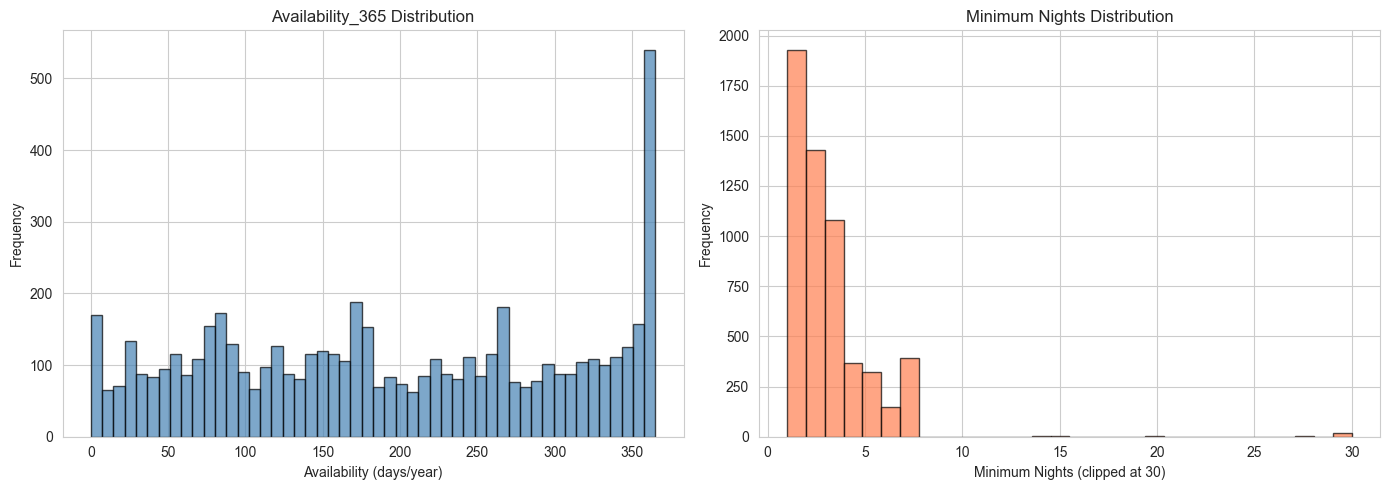

In [15]:
# Availability and Minimum Nights
print("=== AVAILABILITY_365 ===")
print(df['availability_365'].describe())

print("\n=== MINIMUM NIGHTS ===")
print(df['minimum_nights'].describe())
print(f"\nListings with minimum_nights > 30 (long-term): {(df['minimum_nights'] > 30).sum()} ({(df['minimum_nights'] > 30).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['availability_365'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Availability (days/year)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Availability_365 Distribution')

# Minimum nights - clip at 30 for visibility
min_nights_clipped = df['minimum_nights'].clip(upper=30)
axes[1].hist(min_nights_clipped, bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Minimum Nights (clipped at 30)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Minimum Nights Distribution')

plt.tight_layout()
plt.show()

## 4. Spatial Distribution Analysis

GeoDataFrame created with 5710 points


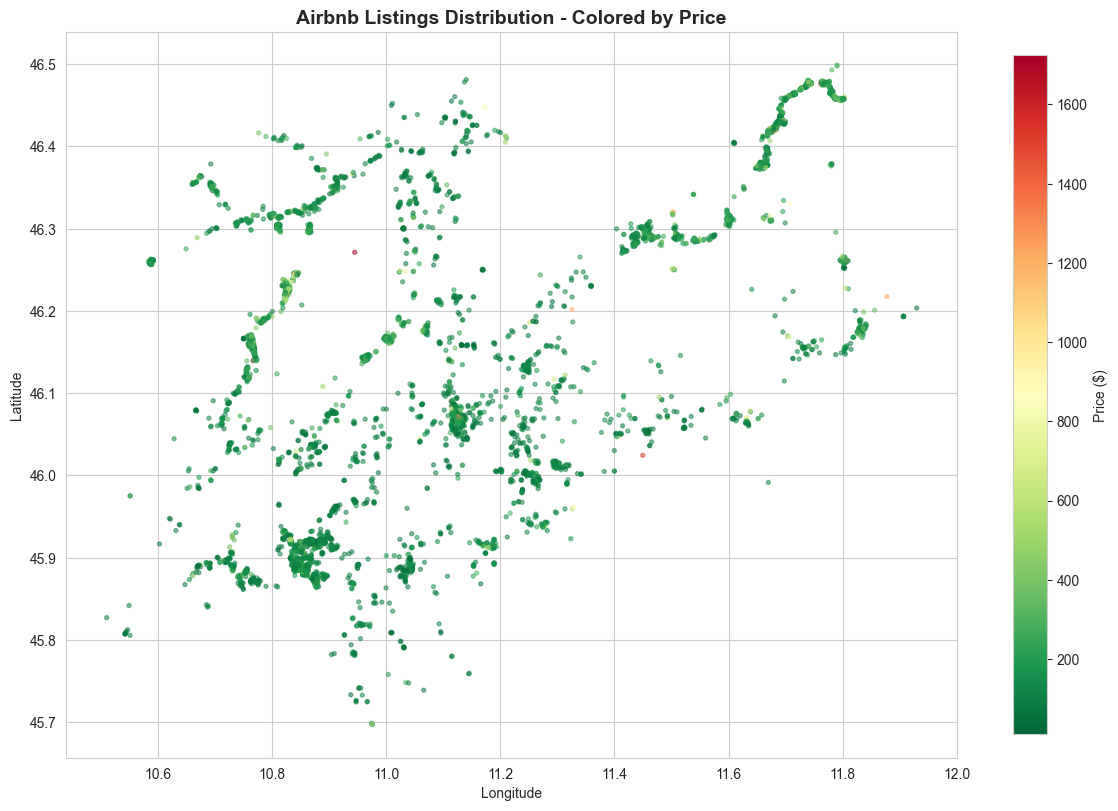

In [16]:
# Convert to GeoDataFrame for mapping
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df.long, df.lat),
    crs='EPSG:4326'
)
print(f"GeoDataFrame created with {len(gdf)} points")

# Map of all listings colored by price
fig, ax = plt.subplots(figsize=(12, 10))
gdf.plot(
    column='price',
    cmap='RdYlGn_r',
    legend=True,
    markersize=8,
    alpha=0.5,
    ax=ax,
    legend_kwds={'label': 'Price ($)', 'shrink': 0.7},
)
ax.set_title('Airbnb Listings Distribution - Colored by Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

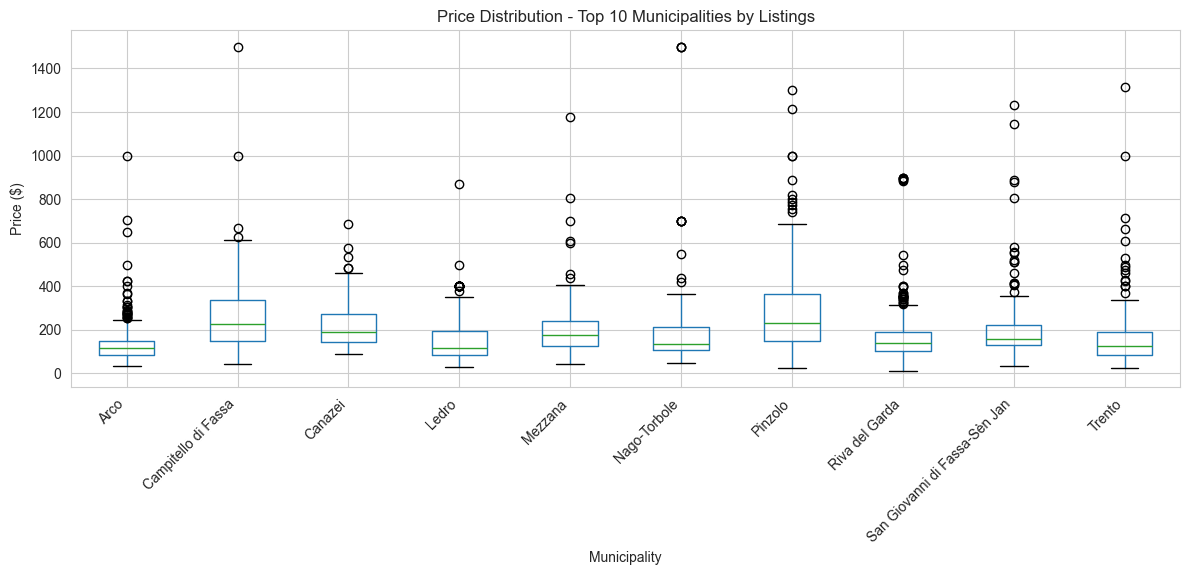

In [17]:
# Price by municipality (top 10)
top_10_municipalities = df['municipality'].value_counts().head(10).index
df_top10 = df[df['municipality'].isin(top_10_municipalities)]

plt.figure(figsize=(12, 6))
df_top10.boxplot(column='price', by='municipality', ax=plt.gca())
plt.xlabel('Municipality')
plt.ylabel('Price ($)')
plt.title('Price Distribution - Top 10 Municipalities by Listings')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# Distance statistics
df_clean = df.copy()
for col in distance_cols:
    df_clean.loc[df_clean[col] == 99999, col] = np.nan

print("=== DISTANCE STATISTICS (meters) ===")
distance_stats = df_clean[distance_cols].describe().T
distance_stats['mean_km'] = distance_stats['mean'] / 1000
distance_stats['median_km'] = distance_stats['50%'] / 1000
print(distance_stats[['mean_km', 'median_km', 'min', 'max']].round(2))

=== DISTANCE STATISTICS (meters) ===
                  mean_km  median_km    min       max
dist_ski             5.66       4.09   0.12  22667.05
dist_lake           10.80       8.09   0.00  38887.32
dist_park            1.29       0.57   0.00  12195.77
dist_station        12.73       6.10  42.38  54141.39
dist_bus             0.26       0.17   0.91   7206.35
dist_center          2.89       2.47  63.77  13588.36
dist_supermarket     0.64       0.35   0.00   8320.70
dist_restaurant      0.39       0.23   0.00   6296.68
dist_bar             0.61       0.30   0.00   7672.60
dist_pharmacy        1.12       0.55   2.78   9914.77
dist_castle          8.29       3.76   0.00  34776.83
dist_museum          2.49       1.94   0.05  12907.89


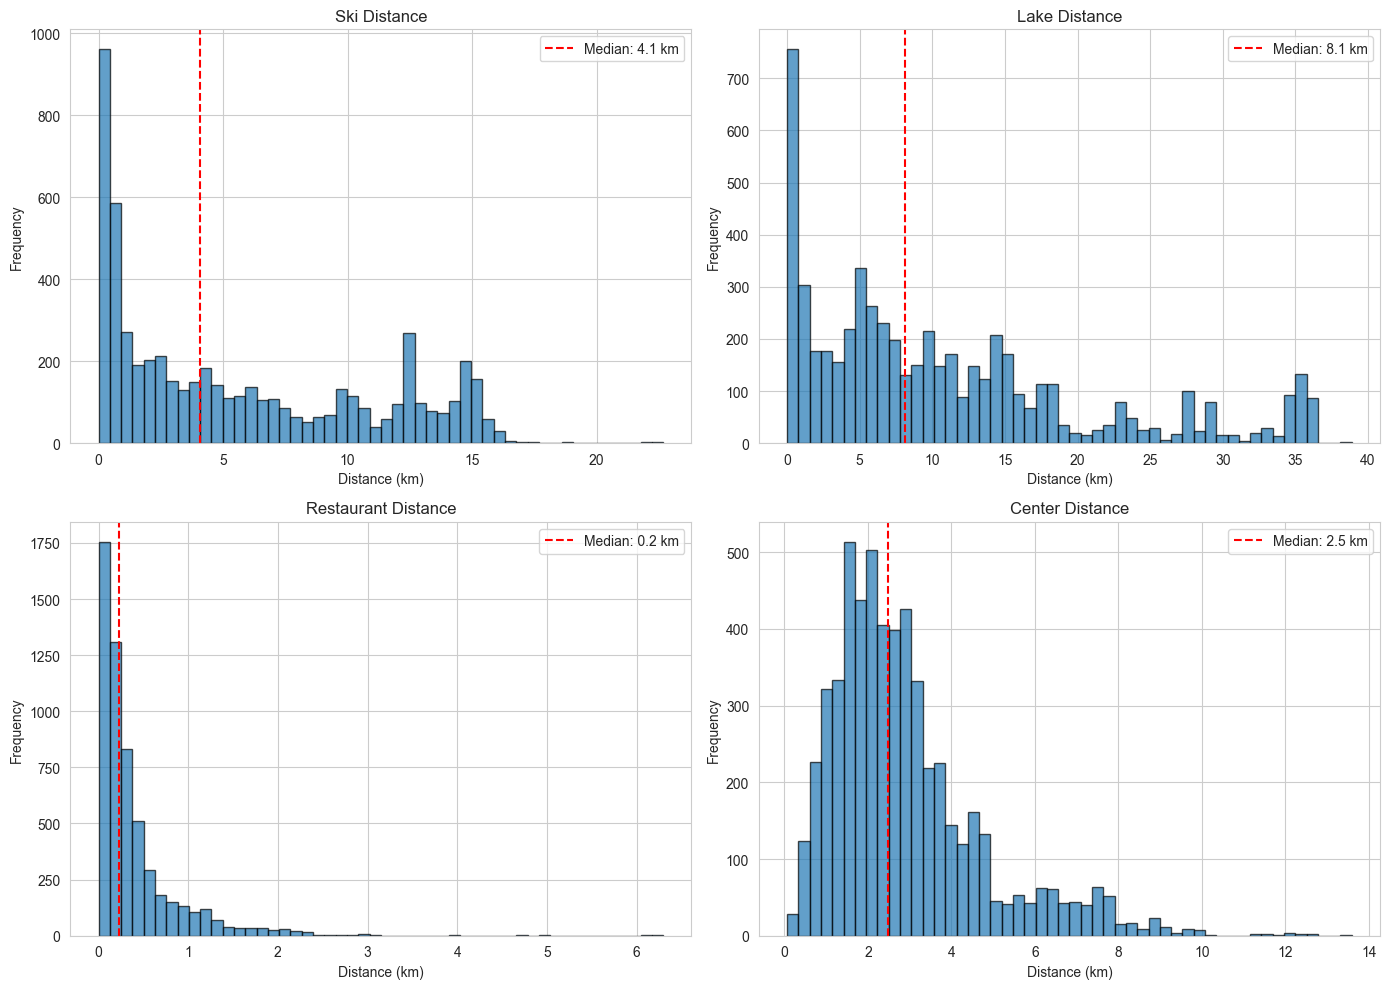

In [19]:
# Distribution of key distances
key_distances = ['dist_ski', 'dist_lake', 'dist_restaurant', 'dist_center']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_distances):
    data = df_clean[col].dropna() / 1000
    axes[i].hist(data, bins=50, edgecolor='black', alpha=0.7)
    axes[i].axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():.1f} km')
    axes[i].set_xlabel('Distance (km)')
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{col.replace("dist_", "").replace("_", " ").title()} Distance')
    axes[i].legend()

plt.tight_layout()
plt.show()

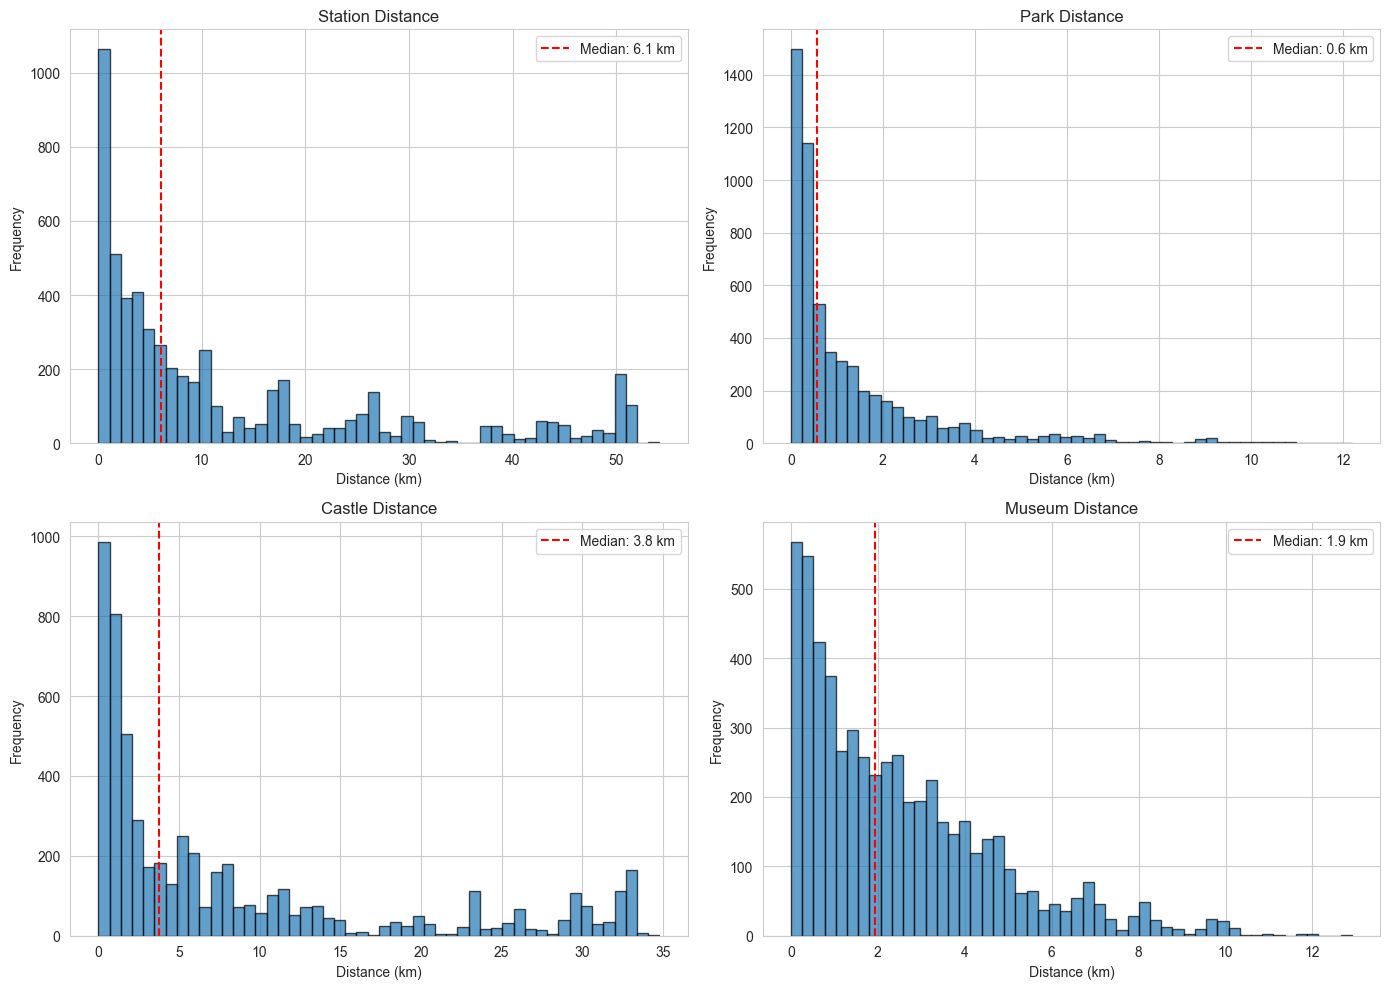

In [20]:
# Additional distance distributions
extra_distances = ['dist_station', 'dist_park', 'dist_castle', 'dist_museum']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(extra_distances):
    data = df_clean[col].dropna() / 1000
    axes[i].hist(data, bins=50, edgecolor='black', alpha=0.7)
    axes[i].axvline(data.median(), color='red', linestyle='--', label=f"Median: {data.median():.1f} km")
    axes[i].set_xlabel('Distance (km)')
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f"{col.replace('dist_', '').replace('_', ' ').title()} Distance")
    axes[i].legend()

plt.tight_layout()
plt.show()

## 5. Correlation Analysis

In [21]:
# Correlation with price - ALL variables (old + new)
numeric_cols = ['price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
                'n_reviews', 'review_scores_rating', 'host_is_superhost',
                'availability_365', 'minimum_nights'] + distance_cols

corr_data = df_clean[numeric_cols]
price_corr = corr_data.corr()['price'].drop('price').sort_values(ascending=False)

print("=== CORRELATION WITH PRICE (all variables) ===")
print(price_corr.round(3))

=== CORRELATION WITH PRICE (all variables) ===
accommodates            0.337
bedrooms                0.264
bathrooms               0.264
beds                    0.247
dist_castle             0.196
dist_station            0.154
dist_lake               0.132
dist_park               0.059
dist_center             0.046
dist_bus                0.038
dist_supermarket        0.032
dist_pharmacy           0.032
minimum_nights          0.018
dist_bar               -0.006
dist_museum            -0.011
review_scores_rating   -0.015
dist_restaurant        -0.026
host_is_superhost      -0.037
availability_365       -0.081
n_reviews              -0.118
dist_ski               -0.186
Name: price, dtype: float64


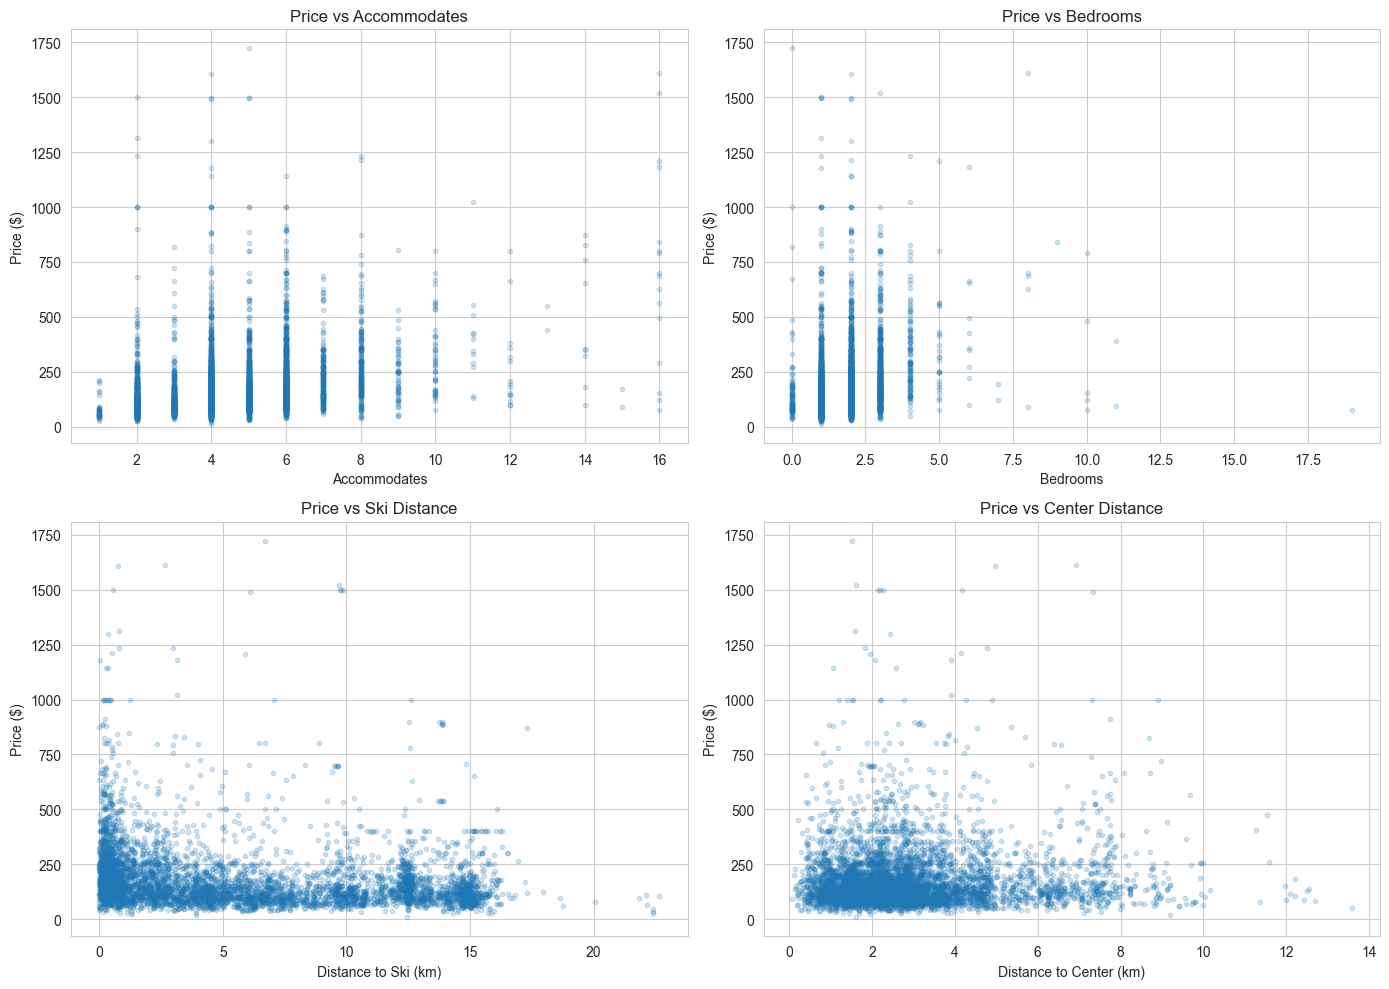

In [22]:
# Price relationships with key drivers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

axes[0].scatter(df['accommodates'], df['price'], alpha=0.2, s=10)
axes[0].set_xlabel('Accommodates')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Price vs Accommodates')

axes[1].scatter(df['bedrooms'], df['price'], alpha=0.2, s=10)
axes[1].set_xlabel('Bedrooms')
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Price vs Bedrooms')

axes[2].scatter(df_clean['dist_ski'] / 1000, df['price'], alpha=0.2, s=10)
axes[2].set_xlabel('Distance to Ski (km)')
axes[2].set_ylabel('Price ($)')
axes[2].set_title('Price vs Ski Distance')

axes[3].scatter(df_clean['dist_center'] / 1000, df['price'], alpha=0.2, s=10)
axes[3].set_xlabel('Distance to Center (km)')
axes[3].set_ylabel('Price ($)')
axes[3].set_title('Price vs Center Distance')

plt.tight_layout()
plt.show()

## EDA Summary

In [23]:
print("="*70)
print("EDA SUMMARY")
print("="*70)

print("\nDataset Overview")
print(f"   Total listings: {len(df):,}")
if 'period' in df.columns:
    period_counts = df['period'].value_counts(dropna=False)
    print(f"   Periods in data: {', '.join([str(p) for p in period_counts.index.tolist()])}")
else:
    print("   Periods in data: not available")
print(f"   Municipalities: {df['municipality'].nunique()}")
print(f"   Property types: {df['property_type'].nunique()}")

print("\nPrice Summary")
print(f"   Range: ${df['price'].min():.0f} - ${df['price'].max():.0f}")
print(f"   Median: ${df['price'].median():.0f}")
print(f"   Mean: ${df['price'].mean():.0f}")
if 'price_per_person' in df.columns:
    print(f"   Price per person median: ${df['price_per_person'].median():.0f}")

print("\nStructural Variables")
print(f"   Bedrooms: {df['bedrooms'].min():.0f}-{df['bedrooms'].max():.0f} (median: {df['bedrooms'].median():.0f})")
print(f"   Beds: {df['beds'].min():.0f}-{df['beds'].max():.0f} (median: {df['beds'].median():.0f})")
print(f"   Bathrooms: {df['bathrooms'].min():.1f}-{df['bathrooms'].max():.1f} (median: {df['bathrooms'].median():.1f})")

print("\nQuality and Host Variables")
print(f"   Review Score: {df['review_scores_rating'].mean():.2f} (median: {df['review_scores_rating'].median():.2f})")
print(f"   Superhosts: {(df['host_is_superhost']==1).sum()} ({(df['host_is_superhost']==1).mean()*100:.1f}%)")
print(f"   Avg availability: {df['availability_365'].mean():.0f} days/year")
print(f"   Median minimum nights: {df['minimum_nights'].median():.0f}")

print("\nSpatial Variables")
print(f"   Distance variables: {len(distance_cols)}")
print("   Key distances (median km):")
for dist in ['dist_center', 'dist_ski', 'dist_lake', 'dist_restaurant']:
    median_km = df_clean[dist].median() / 1000
    print(f"      {dist.replace('dist_', '')}: {median_km:.2f} km")

print("\nTop 5 Municipalities (by listings)")
for i, (muni, count) in enumerate(df['municipality'].value_counts().head(5).items(), 1):
    avg_price = df[df['municipality']==muni]['price'].mean()
    print(f"   {i}. {muni}: {count} listings (avg ${avg_price:.0f})")

EDA SUMMARY

Dataset Overview
   Total listings: 5,710
   Periods in data: december
   Municipalities: 157
   Property types: 52

Price Summary
   Range: $10 - $1724
   Median: $140
   Mean: $179
   Price per person median: $34

Structural Variables
   Bedrooms: 0-19 (median: 2)
   Beds: 0-50 (median: 3)
   Bathrooms: 0.0-19.0 (median: 1.0)

Quality and Host Variables
   Review Score: 4.77 (median: 4.88)
   Superhosts: 1780 (31.2%)
   Avg availability: 195 days/year
   Median minimum nights: 2

Spatial Variables
   Distance variables: 12
   Key distances (median km):
      center: 2.47 km
      ski: 4.09 km
      lake: 8.09 km
      restaurant: 0.23 km

Top 5 Municipalities (by listings)
   1. Riva del Garda: 559 listings (avg $165)
   2. Trento: 379 listings (avg $154)
   3. Arco: 365 listings (avg $135)
   4. Pinzolo: 244 listings (avg $287)
   5. Ledro: 205 listings (avg $165)


In [25]:
# Key findings summary
print("\n" + "="*70)
print("KEY FINDINGS (EDA)")
print("="*70)

print("\nStrongest Price Correlations:")
top_corr = price_corr.head(5)
for var, corr in top_corr.items():
    print(f"   {var.replace('_', ' ').title()}: {corr:+.3f}")

print("\nMost Negative Correlations:")
bottom_corr = price_corr.tail(5)
for var, corr in bottom_corr.items():
    print(f"   {var.replace('_', ' ').replace('dist ', 'Distance to ').title()}: {corr:+.3f}")

print("\n" + "="*70)


KEY FINDINGS (EDA)

Strongest Price Correlations:
   Accommodates: +0.337
   Bedrooms: +0.264
   Bathrooms: +0.264
   Beds: +0.247
   Dist Castle: +0.196

Most Negative Correlations:
   Distance To Restaurant: -0.026
   Host Is Superhost: -0.037
   Availability 365: -0.081
   N Reviews: -0.118
   Distance To Ski: -0.186

